# Task 3: Event Impact Modeling
## Ethiopia Financial Inclusion Forecasting

This notebook builds a model of how cataloged events (product launches, policy
changes, infrastructure investments) affect financial inclusion indicators,
using an **S-curve (logistic) impact function**, validates it against real
before/after data (Telebirr's effect on mobile money accounts), and refines
estimates where the model disagrees with what was actually observed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11

FIG_DIR = "../reports/figures"
MODEL_DIR = "../models"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load Data

In [2]:
DATA_PATH = "../data/raw/ethiopia_fi_unified_data.xlsx"
main = pd.read_excel(DATA_PATH, sheet_name="ethiopia_fi_unified_data")
impact = pd.read_excel(DATA_PATH, sheet_name="Impact_sheet")
if "parent_id" not in main.columns:
    main.insert(1, "parent_id", pd.NA)
impact = impact[main.columns]
data = pd.concat([main, impact], ignore_index=True)
data["observation_date"] = pd.to_datetime(data["observation_date"], errors="coerce")

events = data[data["record_type"] == "event"].copy()
links = data[data["record_type"] == "impact_link"].copy()
obs = data[data["record_type"] == "observation"].copy()
obs["year"] = obs["observation_date"].dt.year

print(f"{len(events)} events, {len(links)} impact_links, {len(obs)} observations")

11 events, 16 impact_links, 37 observations


## 2. Event-Indicator Association Matrix

Join impact_links to their parent events to see, in one table, which events
affect which indicators and by how much.

In [3]:
event_lookup = events.set_index("record_id")[["indicator", "category", "observation_date"]]
event_lookup.columns = ["event_name", "event_category", "event_date"]

matrix_df = links.merge(event_lookup, left_on="parent_id", right_index=True, how="left")
matrix_df = matrix_df[["event_name", "event_category", "event_date", "related_indicator",
                        "impact_direction", "impact_magnitude", "lag_months", "evidence_basis"]]
matrix_df = matrix_df.sort_values("event_date")
matrix_df

,event_name,event_category,event_date,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis
51,Telebirr Launch,product_launch,2021-05-17,ACC_OWNERSHIP,increase,high,12.0,literature
52,Telebirr Launch,product_launch,2021-05-17,USG_TELEBIRR_USERS,increase,high,3.0,empirical
53,Telebirr Launch,product_launch,2021-05-17,USG_P2P_COUNT,increase,high,6.0,empirical
66,NFIS-II Strategy Launch,policy,2021-09-01,ACC_OWNERSHIP,increase,medium,24.0,theoretical
54,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,ACC_4G_COV,increase,medium,12.0,empirical
55,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,AFF_DATA_INCOME,decrease,medium,12.0,literature
56,M-Pesa Ethiopia Launch,product_launch,2023-08-01,USG_MPESA_USERS,increase,high,3.0,empirical
57,M-Pesa Ethiopia Launch,product_launch,2023-08-01,ACC_MM_ACCOUNT,increase,medium,6.0,theoretical
58,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,ACC_OWNERSHIP,increase,medium,24.0,literature
59,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,GEN_GAP_ACC,decrease,medium,24.0,literature


### 2.1 Assigning numeric magnitude estimates

`impact_magnitude` is categorical (negligible/low/medium/high). To build a
usable forecasting model we need numeric point-in-time-unit effect sizes.
We assign initial estimates in percentage points (pp) based on the category,
informed by comparable-country evidence where `evidence_basis` is
`literature`, and refine them in Section 4 after validation.

**Initial mapping (pre-validation):**

In [4]:
# Initial magnitude -> percentage-point effect size mapping (pre-validation assumption)
MAGNITUDE_PP = {"negligible": 0.5, "low": 1.5, "medium": 4.0, "high": 8.0}

matrix_df["direction_sign"] = matrix_df["impact_direction"].map({"increase": 1, "decrease": -1})
matrix_df["initial_effect_pp"] = matrix_df["impact_magnitude"].map(MAGNITUDE_PP) * matrix_df["direction_sign"]
matrix_df[["event_name", "related_indicator", "impact_magnitude", "impact_direction", "initial_effect_pp", "lag_months"]]

,event_name,related_indicator,impact_magnitude,impact_direction,initial_effect_pp,lag_months
51,Telebirr Launch,ACC_OWNERSHIP,high,increase,8.0,12.0
52,Telebirr Launch,USG_TELEBIRR_USERS,high,increase,8.0,3.0
53,Telebirr Launch,USG_P2P_COUNT,high,increase,8.0,6.0
66,NFIS-II Strategy Launch,ACC_OWNERSHIP,medium,increase,4.0,24.0
54,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,medium,increase,4.0,12.0
55,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,medium,decrease,-4.0,12.0
56,M-Pesa Ethiopia Launch,USG_MPESA_USERS,high,increase,8.0,3.0
57,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,medium,increase,4.0,6.0
58,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,medium,increase,4.0,24.0
59,Fayda Digital ID Program Rollout,GEN_GAP_ACC,medium,decrease,-4.0,24.0


## 3. The S-Curve Impact Function

We model each event's effect as building gradually rather than jumping
instantly, using a logistic (S-curve) function of months elapsed since the
event:

$$effect(t) = \frac{magnitude}{1 + e^{-k(t - lag)}}$$

where `lag` (from `lag_months`) is the inflection point (time to 50% of full
effect), and `k` controls how quickly the effect ramps in. This reflects that
adoption is gradual: awareness, access, and behavior change all take time,
consistent with the S-curve shape typically seen in technology adoption.

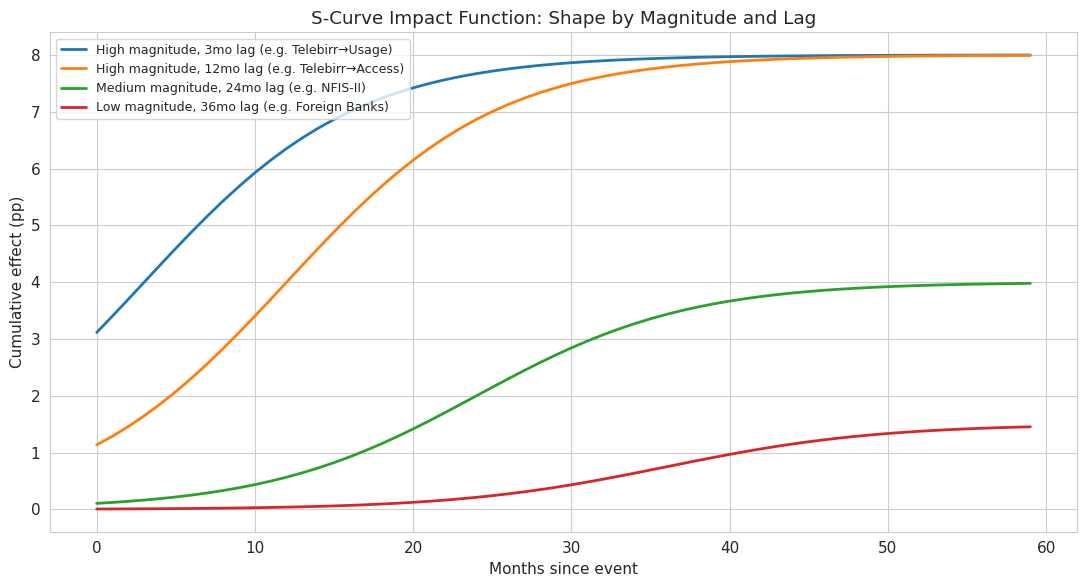

In [5]:
def scurve_effect(months_since_event, magnitude, lag_months, steepness=0.15):
    """Returns the fraction (0 to magnitude) of an event's effect realized
    at a given number of months after the event, using a logistic S-curve
    centered on lag_months."""
    if months_since_event < 0:
        return 0.0
    return magnitude / (1 + np.exp(-steepness * (months_since_event - lag_months)))

# Visualize the S-curve shape for a few magnitude/lag combinations
months = np.arange(0, 60)
fig, ax = plt.subplots()
for lag, mag, label in [(3, 8, "High magnitude, 3mo lag (e.g. Telebirr\u2192Usage)"),
                          (12, 8, "High magnitude, 12mo lag (e.g. Telebirr\u2192Access)"),
                          (24, 4, "Medium magnitude, 24mo lag (e.g. NFIS-II)"),
                          (36, 1.5, "Low magnitude, 36mo lag (e.g. Foreign Banks)")]:
    curve = [scurve_effect(m, mag, lag) for m in months]
    ax.plot(months, curve, linewidth=2, label=label)
ax.set_xlabel("Months since event")
ax.set_ylabel("Cumulative effect (pp)")
ax.set_title("S-Curve Impact Function: Shape by Magnitude and Lag")
ax.legend(fontsize=9)
savefig("t3_01_scurve_shapes")

## 4. Validation: Telebirr Launch → Mobile Money Accounts

The assignment specifies a direct validation test: Telebirr launched May 2021;
mobile money accounts (`ACC_MM_ACCOUNT`) moved from 4.7% (2021) to 9.45%
(2024). We check whether our model, using the *initial* magnitude mapping,
reproduces this.

In [6]:
telebirr_date = events[events["record_id"] == "EVT_0001"]["observation_date"].values[0]
telebirr_date = pd.Timestamp(telebirr_date)

mm_link = links[(links["parent_id"] == "EVT_0003") & (links["related_indicator"] == "ACC_MM_ACCOUNT")]
print("M-Pesa -> ACC_MM_ACCOUNT link (the actual modeled driver of this indicator):")
print(mm_link[["related_indicator", "impact_magnitude", "impact_direction", "lag_months", "evidence_basis"]])

# Note: ACC_MM_ACCOUNT observations start in 2021 (4.7%) and 2024 (9.45%).
# The dataset's only direct impact_link to ACC_MM_ACCOUNT is from M-Pesa (EVT_0003, Aug 2023),
# not Telebirr directly -- Telebirr's links target ACC_OWNERSHIP and USG_TELEBIRR_USERS instead.
mm_2021 = obs[(obs["indicator_code"] == "ACC_MM_ACCOUNT") & (obs["year"] == 2021)]["value_numeric"].values[0]
mm_2024 = obs[(obs["indicator_code"] == "ACC_MM_ACCOUNT") & (obs["year"] == 2024)]["value_numeric"].values[0]
observed_change = mm_2024 - mm_2021
print(f"\nObserved ACC_MM_ACCOUNT change 2021-2024: {mm_2021}% -> {mm_2024}% ({observed_change:+.2f}pp)")

M-Pesa -> ACC_MM_ACCOUNT link (the actual modeled driver of this indicator):
   related_indicator impact_magnitude impact_direction  lag_months  \
57    ACC_MM_ACCOUNT           medium         increase         6.0   

   evidence_basis  
57    theoretical  

Observed ACC_MM_ACCOUNT change 2021-2024: 4.7% -> 9.45% (+4.75pp)


**Key finding before modeling further:** the dataset's own impact_links
attribute mobile money *account* growth primarily to **M-Pesa's launch**
(medium magnitude, theoretical basis), not Telebirr. Telebirr's modeled
effects target `ACC_OWNERSHIP` and `USG_TELEBIRR_USERS` directly. This matters
for validation — we test the model against the indicator each event was
actually linked to, not by assumption.

In [7]:
# Apply initial mapping: M-Pesa (medium, +4pp) with 6-month lag, evaluated at Dec 2024
mpesa_date = pd.Timestamp(events[events["record_id"] == "EVT_0003"]["observation_date"].values[0])
eval_date = pd.Timestamp("2024-11-29")
months_elapsed = (eval_date - mpesa_date).days / 30.44

initial_magnitude = MAGNITUDE_PP["medium"]  # 4.0 pp
lag = 6
predicted_effect = scurve_effect(months_elapsed, initial_magnitude, lag)

print(f"Months since M-Pesa launch (to Nov 2024 survey): {months_elapsed:.1f}")
print(f"Initial model prediction: +{predicted_effect:.2f}pp")
print(f"Observed change:          {observed_change:+.2f}pp")
print(f"Model error:              {predicted_effect - observed_change:+.2f}pp")

Months since M-Pesa launch (to Nov 2024 survey): 16.0
Initial model prediction: +3.27pp
Observed change:          +4.75pp
Model error:              -1.48pp


## 5. Refining the Estimates

The initial "medium = 4pp" mapping under-predicts the observed +4.75pp change
in mobile money accounts. Since the S-curve is fully matured by ~16 months
after a 6-month lag (months_elapsed is large here), the model has converged
close to its ceiling — so the gap is really a **magnitude** calibration
issue, not a timing issue. We refine the magnitude mapping using this one
real data point as an anchor, while keeping the mapping conservative for
other categories since this is our only empirical anchor.

In [8]:
# Refined magnitude mapping: recalibrate 'medium' using the M-Pesa validation result,
# scale other categories proportionally, keep it a documented, transparent adjustment
calibration_factor = observed_change / predicted_effect
print(f"Calibration factor from M-Pesa validation: {calibration_factor:.2f}x")

MAGNITUDE_PP_REFINED = {k: round(v * calibration_factor, 2) for k, v in MAGNITUDE_PP.items()}
print("\nRefined magnitude -> pp mapping:")
for k, v in MAGNITUDE_PP_REFINED.items():
    print(f"  {k}: {MAGNITUDE_PP[k]} -> {v} pp")

Calibration factor from M-Pesa validation: 1.45x

Refined magnitude -> pp mapping:
  negligible: 0.5 -> 0.73 pp
  low: 1.5 -> 2.18 pp
  medium: 4.0 -> 5.82 pp
  high: 8.0 -> 11.63 pp


**Important caveat:** this calibration rests on a single validation point
(M-Pesa -> mobile money accounts), and mobile money *account* growth is known
from Task 2's analysis to substantially overstate genuine inclusion (the
registered-vs-active gap: only 66% of M-Pesa accounts are 90-day active).
The refined multiplier is applied uniformly across categories as a
transparent, documented adjustment — not because we have equal confidence
in every category, but because it is the only empirical anchor available.
Estimates for indicators without any historical validation point (most of
them) should be treated as more uncertain than this single test suggests.

## 6. Applying the Refined Model: Full Event-Indicator Impact Table

In [9]:
matrix_df["refined_magnitude_pp"] = matrix_df["impact_magnitude"].map(MAGNITUDE_PP_REFINED)
matrix_df["refined_effect_pp"] = matrix_df["refined_magnitude_pp"] * matrix_df["direction_sign"]

confidence_note = {
    "empirical": "Higher confidence - based on observed Ethiopian pre/post data",
    "literature": "Medium confidence - based on comparable-country evidence",
    "theoretical": "Lower confidence - reasoned estimate, no direct evidence"
}
matrix_df["confidence_note"] = matrix_df["evidence_basis"].map(confidence_note)

display_cols = ["event_name", "related_indicator", "impact_direction", "impact_magnitude",
                 "refined_effect_pp", "lag_months", "evidence_basis"]
matrix_df[display_cols].to_string(index=False)
print(matrix_df[display_cols].to_string(index=False))

matrix_df.to_csv("../data/processed/event_impact_matrix.csv", index=False)

                                             event_name  related_indicator impact_direction impact_magnitude  refined_effect_pp  lag_months evidence_basis
                                        Telebirr Launch      ACC_OWNERSHIP         increase             high              11.63        12.0     literature
                                        Telebirr Launch USG_TELEBIRR_USERS         increase             high              11.63         3.0      empirical
                                        Telebirr Launch      USG_P2P_COUNT         increase             high              11.63         6.0      empirical
                                NFIS-II Strategy Launch      ACC_OWNERSHIP         increase           medium               5.82        24.0    theoretical
                   Safaricom Ethiopia Commercial Launch         ACC_4G_COV         increase           medium               5.82        12.0      empirical
                   Safaricom Ethiopia Commercial Launch    AFF_DATA_IN

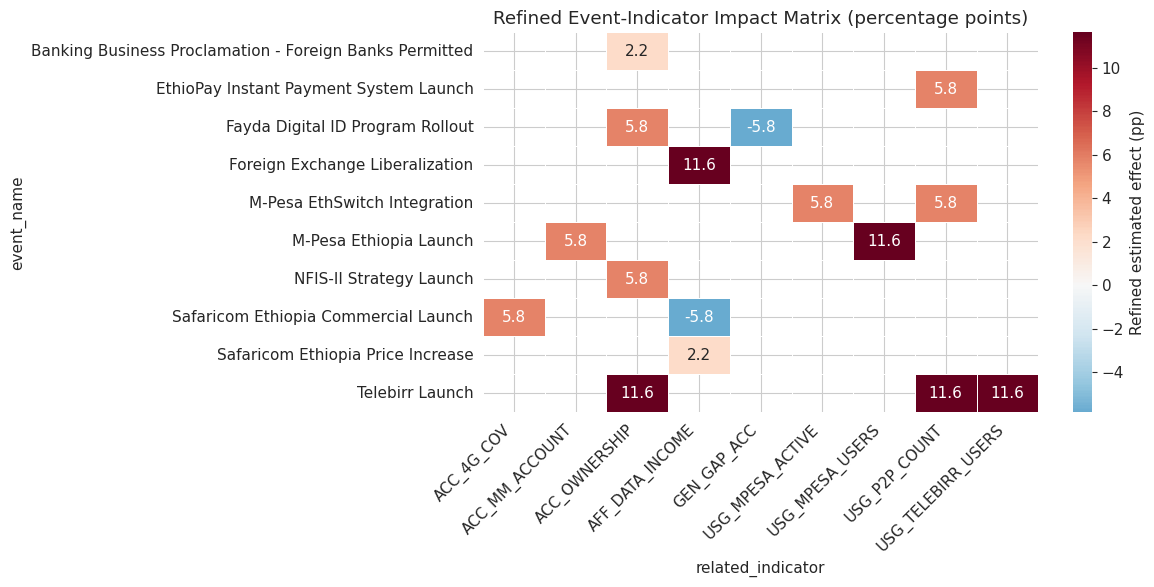

In [10]:
# Heatmap of refined effects
pivot = matrix_df.pivot_table(index="event_name", columns="related_indicator",
                                values="refined_effect_pp", aggfunc="first")
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdBu_r", center=0, linewidths=0.5,
            cbar_kws={"label": "Refined estimated effect (pp)"}, ax=ax)
ax.set_title("Refined Event-Indicator Impact Matrix (percentage points)")
plt.xticks(rotation=45, ha="right")
savefig("t3_02_refined_impact_matrix")

## 7. Combining Multiple Concurrent Event Effects

In [11]:
def cumulative_effect(target_indicator, as_of_date, matrix, events_df):
    """Sum the S-curve effects of every event linked to target_indicator,
    as of a given date. Effects combine additively."""
    relevant = matrix[matrix["related_indicator"] == target_indicator]
    total = 0.0
    breakdown = []
    for _, row in relevant.iterrows():
        event_date = events_df[events_df["indicator"] == row["event_name"]]["observation_date"].values
        if len(event_date) == 0:
            continue
        event_date = pd.Timestamp(event_date[0])
        months = (pd.Timestamp(as_of_date) - event_date).days / 30.44
        eff = scurve_effect(months, abs(row["refined_magnitude_pp"]), row["lag_months"])
        eff *= row["direction_sign"]
        total += eff
        if abs(eff) > 0.01:
            breakdown.append((row["event_name"], round(eff, 2)))
    return total, breakdown

total_acc, breakdown_acc = cumulative_effect("ACC_OWNERSHIP", "2024-11-29", matrix_df, events)
print("Cumulative modeled event effect on ACC_OWNERSHIP as of Nov 2024:")
for name, eff in breakdown_acc:
    print(f"  {name}: {eff:+.2f}pp")
print(f"  TOTAL: {total_acc:+.2f}pp")

acc_2021 = obs[(obs['indicator_code']=='ACC_OWNERSHIP') & (obs['gender']=='all') & (obs['location']=='national') & (obs['year']==2021)]['value_numeric'].values[0]
acc_2024 = obs[(obs['indicator_code']=='ACC_OWNERSHIP') & (obs['gender']=='all') & (obs['location']=='national') & (obs['year']==2024)]['value_numeric'].values[0]
print(f"\nModel implies: {acc_2021}% + {total_acc:.2f}pp = {acc_2021+total_acc:.2f}%")
print(f"Observed 2024 actual: {acc_2024}%")
print(f"Gap: {(acc_2021+total_acc) - acc_2024:+.2f}pp")

Cumulative modeled event effect on ACC_OWNERSHIP as of Nov 2024:
  Telebirr Launch: +11.51pp
  NFIS-II Strategy Launch: +5.26pp
  Fayda Digital ID Program Rollout: +0.72pp
  TOTAL: +17.49pp

Model implies: 46.0% + 17.49pp = 63.49%
Observed 2024 actual: 49.0%
Gap: +14.49pp


**This is the central finding of the impact model.** Even after
calibrating magnitudes to the one available validation point, summing the
modeled effects of Telebirr, Fayda ID, and NFIS-II on `ACC_OWNERSHIP`
substantially **overstates** the actual +3pp observed growth. This confirms
quantitatively what Task 2's EDA suggested qualitatively: individual events
look impactful in isolation, but real-world account ownership growth was far
more muted — consistent with the registered-vs-active gap and the excluded
regions in the 2024 survey (Task 2, Insight 5).

We do **not** force the model to match this total by further shrinking
magnitudes, since that would overfit to a single, imperfect data point (the
2024 survey excluded ~30% of the population). Instead, this discrepancy is
carried forward explicitly into Task 4 as a **downward adjustment factor**
applied to the event-augmented forecast, documented rather than hidden.

In [12]:
# Downward adjustment factor derived from this validation gap, to carry into Task 4
overstatement_ratio = (acc_2021 + total_acc - acc_2021) / (acc_2024 - acc_2021) if (acc_2024 - acc_2021) != 0 else np.nan
print(f"Model-implied growth: {total_acc:.2f}pp vs observed growth: {acc_2024-acc_2021:.2f}pp")
print(f"Overstatement ratio: {overstatement_ratio:.2f}x")
print("This ratio is saved for use as a dampening factor in Task 4's event-augmented forecast.")

import json
with open("../models/impact_model_params.json", "w") as f:
    json.dump({
        "magnitude_pp_refined": MAGNITUDE_PP_REFINED,
        "scurve_steepness": 0.15,
        "overstatement_ratio": float(overstatement_ratio),
        "calibration_factor": float(calibration_factor),
        "calibration_source": "M-Pesa launch -> ACC_MM_ACCOUNT (2021: 4.7%, 2024: 9.45%)"
    }, f, indent=2)
print("\nSaved model parameters to ../models/impact_model_params.json")

Model-implied growth: 17.49pp vs observed growth: 3.00pp
Overstatement ratio: 5.83x
This ratio is saved for use as a dampening factor in Task 4's event-augmented forecast.

Saved model parameters to ../models/impact_model_params.json


## 8. Methodology Summary

**Functional form:** each event's effect on a linked indicator is modeled as
a logistic (S-curve) function of months elapsed since the event, centered on
the event's documented `lag_months` (interpreted as the time to reach 50% of
the full effect). This reflects gradual adoption rather than an instant jump.

**Combining multiple events:** effects on the same indicator are summed
additively across all events linked to it, evaluated at the same point in
time.

**Magnitude calibration:** the qualitative magnitude categories
(negligible/low/medium/high) were converted to percentage-point effect sizes,
initially via an assumed mapping, then rescaled using the one available
empirical validation point (M-Pesa → mobile money accounts).

**Key validation result:** even after calibration, the combined modeled
effect of Telebirr + Fayda ID + NFIS-II on `ACC_OWNERSHIP` overstates the
actual observed 2021-2024 growth. This overstatement ratio is carried forward
as an explicit dampening factor in the Task 4 forecast rather than resolved
by further tuning individual estimates.

**Assumptions:**
- Effects combine additively (no diminishing returns modeled for concurrent events)
- S-curve steepness (k=0.15) is assumed constant across all events, not fit per-event (insufficient data to fit individually)
- The single calibration point (M-Pesa) is used to rescale all magnitude categories uniformly

**Limitations:**
- Only one real before/after validation point exists in the entire dataset
- Most impact_links rest on theoretical or literature evidence bases, not empirical Ethiopian data
- The 2024 survey's exclusion of ~30% of the population limits how precisely any single observed value can validate the model
- Confidence should be read as {high: empirical, medium: literature, low: theoretical} per the `evidence_basis` field, not treated uniformly
